# MNIST Transfer Attack Comparison

This notebook generates FGSM adversarial examples against the locally trained MNIST model, then evaluates those same perturbed images on two downloaded MNIST classifiers:

- `foxnat/mnist-classifier-hf`: a feed-forward classifier.
- `cmaeti/mnist-cnn`: a convolutional classifier.

The question being tested is whether adversarial examples made for one model also fool other models trained on the same dataset.

## Imports

In [11]:
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from huggingface_hub import PyTorchModelHubMixin, hf_hub_download
from safetensors.torch import load_file

## Local model architecture

This must match the model trained in `mnist_classification.ipynb` so the local checkpoint can be loaded.

In [12]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = nn.Flatten()
        self.hidden_layer1 = nn.Sequential(
            nn.Linear(in_features=28 * 28, out_features=512),
            nn.ReLU(),
        )
        self.hidden_layer2 = nn.Sequential(
            nn.Linear(in_features=512, out_features=512),
            nn.ReLU(),
        )
        self.output_layer = nn.Linear(in_features=512, out_features=10)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layer1(x)
        x = self.hidden_layer2(x)
        return self.output_layer(x)

## Downloaded model architectures

`foxnat/mnist-classifier-hf` stores these feed-forward layers in `model.safetensors`: `input_layer`, `hidden_1`, `hidden_2`, and `output_layer`.

`cmaeti/mnist-cnn` stores a standard small MNIST CNN: `conv1`, `conv2`, `fc1`, and `fc2`.

In [13]:
class ClassifierHF(nn.Module, PyTorchModelHubMixin):
    def __init__(self, input_size=784, num_classes=10):
        super().__init__()
        self.input_layer = nn.Linear(input_size, 512)
        self.hidden_1 = nn.Linear(512, 256)
        self.hidden_2 = nn.Linear(256, 128)
        self.output_layer = nn.Linear(128, num_classes)

    def forward(self, x):
        if x.dim() > 2:
            x = torch.flatten(x, start_dim=1)
        x = F.relu(self.input_layer(x))
        x = F.relu(self.hidden_1(x))
        x = F.relu(self.hidden_2(x))
        return self.output_layer(x)


class CnnDigits(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

## Dataset

In [14]:
test_data = datasets.MNIST(
    root="./data",
    train=False,
    transform=ToTensor(),
    download=True,
)

test_dataloader = DataLoader(
    test_data,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

print(f"Test examples: {len(test_data)}")

Test examples: 10000


## Load models

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

source_mlp = NeuralNetwork().to(device)

# Set this manually if you want a specific checkpoint, or leave None for newest.
checkpoint_to_load = None

checkpoints = sorted(Path("checkpoints").glob("model_*"), key=lambda path: path.stat().st_mtime)
if checkpoint_to_load is None:
    if not checkpoints:
        raise FileNotFoundError("No local checkpoint found. Run mnist_classification.ipynb first.")
    checkpoint_path = checkpoints[-1]
else:
    checkpoint_path = Path(checkpoint_to_load)

print(f"Loading local checkpoint: {checkpoint_path}")
source_mlp.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
source_mlp.eval()

# Downloaded feed-forward MNIST model requested for comparison.
fox_mlp = ClassifierHF.from_pretrained("foxnat/mnist-classifier-hf")
fox_mlp = fox_mlp.to(device)
fox_mlp.eval()

# Downloaded CNN MNIST model for a different architecture comparison.
cnn_weights_path = hf_hub_download(
    repo_id="cmaeti/mnist-cnn",
    filename="mnist-cnn.safetensors",
)
conv_cnn = CnnDigits().to(device)
conv_cnn.load_state_dict(load_file(cnn_weights_path, device=str(device)))
conv_cnn.eval()

target_models = {
    "fox_mlp": fox_mlp,
    "conv_cnn": conv_cnn,
}

all_models = {
    "source_mlp": source_mlp,
    **target_models,
}

print("Loaded models: source_mlp, fox_mlp, conv_cnn")

Device: cpu
Loading local checkpoint: checkpoints\model_2026_04_27_14_33_12_e_2
Loaded models: source_mlp, fox_mlp, conv_cnn


## Helper functions

In [16]:
def predict(model, images):
    return model(images).argmax(dim=1)


def clean_accuracy(model, dataloader, device):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            preds = predict(model, images)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total


def fgsm(image, epsilon, image_grad):
    perturbed_image = image + epsilon * image_grad.sign()
    return torch.clamp(perturbed_image, 0, 1)


def transfer_attack_test(dataloader, source_model, target_models, device, epsilon):
    loss_function = nn.CrossEntropyLoss()
    source_correct_after_attack = 0
    target_stats = {
        name: {"clean_correct": 0, "adv_correct": 0}
        for name in target_models
    }
    attacked_count = 0
    examples = []

    source_model.eval()
    for target_model in target_models.values():
        target_model.eval()

    for image, label in dataloader:
        image, label = image.to(device), label.to(device)
        image.requires_grad = True

        source_output = source_model(image)
        source_initial_pred = source_output.argmax(dim=1)

        # Generate attacks only from examples the source model initially classifies correctly.
        if source_initial_pred.item() != label.item():
            continue

        attacked_count += 1

        target_clean_preds = {}
        with torch.no_grad():
            for name, target_model in target_models.items():
                target_clean_pred = predict(target_model, image)
                target_clean_preds[name] = target_clean_pred.item()
                target_stats[name]["clean_correct"] += (target_clean_pred == label).sum().item()

        loss = loss_function(source_output, label)
        source_model.zero_grad()
        loss.backward()

        adv_image = fgsm(image, epsilon, image.grad.data).detach()

        target_adv_preds = {}
        with torch.no_grad():
            source_adv_pred = predict(source_model, adv_image)
            for name, target_model in target_models.items():
                target_adv_pred = predict(target_model, adv_image)
                target_adv_preds[name] = target_adv_pred.item()
                target_stats[name]["adv_correct"] += (target_adv_pred == label).sum().item()

        source_correct_after_attack += (source_adv_pred == label).sum().item()

        if len(examples) < 5 and (epsilon == 0 or source_adv_pred.item() != label.item()):
            examples.append({
                "label": label.item(),
                "source_before": source_initial_pred.item(),
                "source_after": source_adv_pred.item(),
                "target_clean": target_clean_preds,
                "target_after": target_adv_preds,
                "image": adv_image.squeeze().cpu(),
            })

    return {
        "epsilon": epsilon,
        "attacked_count": attacked_count,
        "source_adv_accuracy": source_correct_after_attack / attacked_count,
        "target_results": {
            name: {
                "clean_accuracy_on_attacked_subset": stats["clean_correct"] / attacked_count,
                "adv_accuracy": stats["adv_correct"] / attacked_count,
            }
            for name, stats in target_stats.items()
        },
        "examples": examples,
    }

## Clean accuracy before attack

In [17]:
for model_name, model in all_models.items():
    accuracy = clean_accuracy(model, test_dataloader, device)
    print(f"{model_name:>10} clean accuracy: {100 * accuracy:.2f}%")

source_mlp clean accuracy: 97.78%
   fox_mlp clean accuracy: 97.10%
  conv_cnn clean accuracy: 98.72%


## FGSM transfer comparison

The adversarial examples are generated using gradients from `source_mlp` only. `fox_mlp` and `conv_cnn` are then evaluated on those same adversarial images.

In [18]:
epsilons = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
results = []

for eps in epsilons:
    result = transfer_attack_test(test_dataloader, source_mlp, target_models, device, eps)
    results.append(result)

    target_summary = " | ".join(
        f"{name} clean subset={100 * scores['clean_accuracy_on_attacked_subset']:>6.2f}% "
        f"adv={100 * scores['adv_accuracy']:>6.2f}%"
        for name, scores in result["target_results"].items()
    )
    print(
        f"eps={eps:>4}: "
        f"source_mlp adv={100 * result['source_adv_accuracy']:>6.2f}% | "
        f"{target_summary} | "
        f"attacked={result['attacked_count']}"
    )

eps=   0: source_mlp adv=100.00% | fox_mlp clean subset= 98.30% adv= 98.30% | conv_cnn clean subset= 99.40% adv= 99.40% | attacked=9778
eps=0.05: source_mlp adv= 75.32% | fox_mlp clean subset= 98.30% adv= 83.14% | conv_cnn clean subset= 99.40% adv= 98.82% | attacked=9778
eps= 0.1: source_mlp adv= 27.69% | fox_mlp clean subset= 98.30% adv= 41.49% | conv_cnn clean subset= 99.40% adv= 97.73% | attacked=9778
eps=0.15: source_mlp adv=  8.52% | fox_mlp clean subset= 98.30% adv= 17.28% | conv_cnn clean subset= 99.40% adv= 95.51% | attacked=9778
eps= 0.2: source_mlp adv=  3.05% | fox_mlp clean subset= 98.30% adv=  8.08% | conv_cnn clean subset= 99.40% adv= 90.57% | attacked=9778
eps=0.25: source_mlp adv=  1.16% | fox_mlp clean subset= 98.30% adv=  4.80% | conv_cnn clean subset= 99.40% adv= 78.93% | attacked=9778
eps= 0.3: source_mlp adv=  0.41% | fox_mlp clean subset= 98.30% adv=  3.26% | conv_cnn clean subset= 99.40% adv= 59.74% | attacked=9778


## Plot adversarial examples

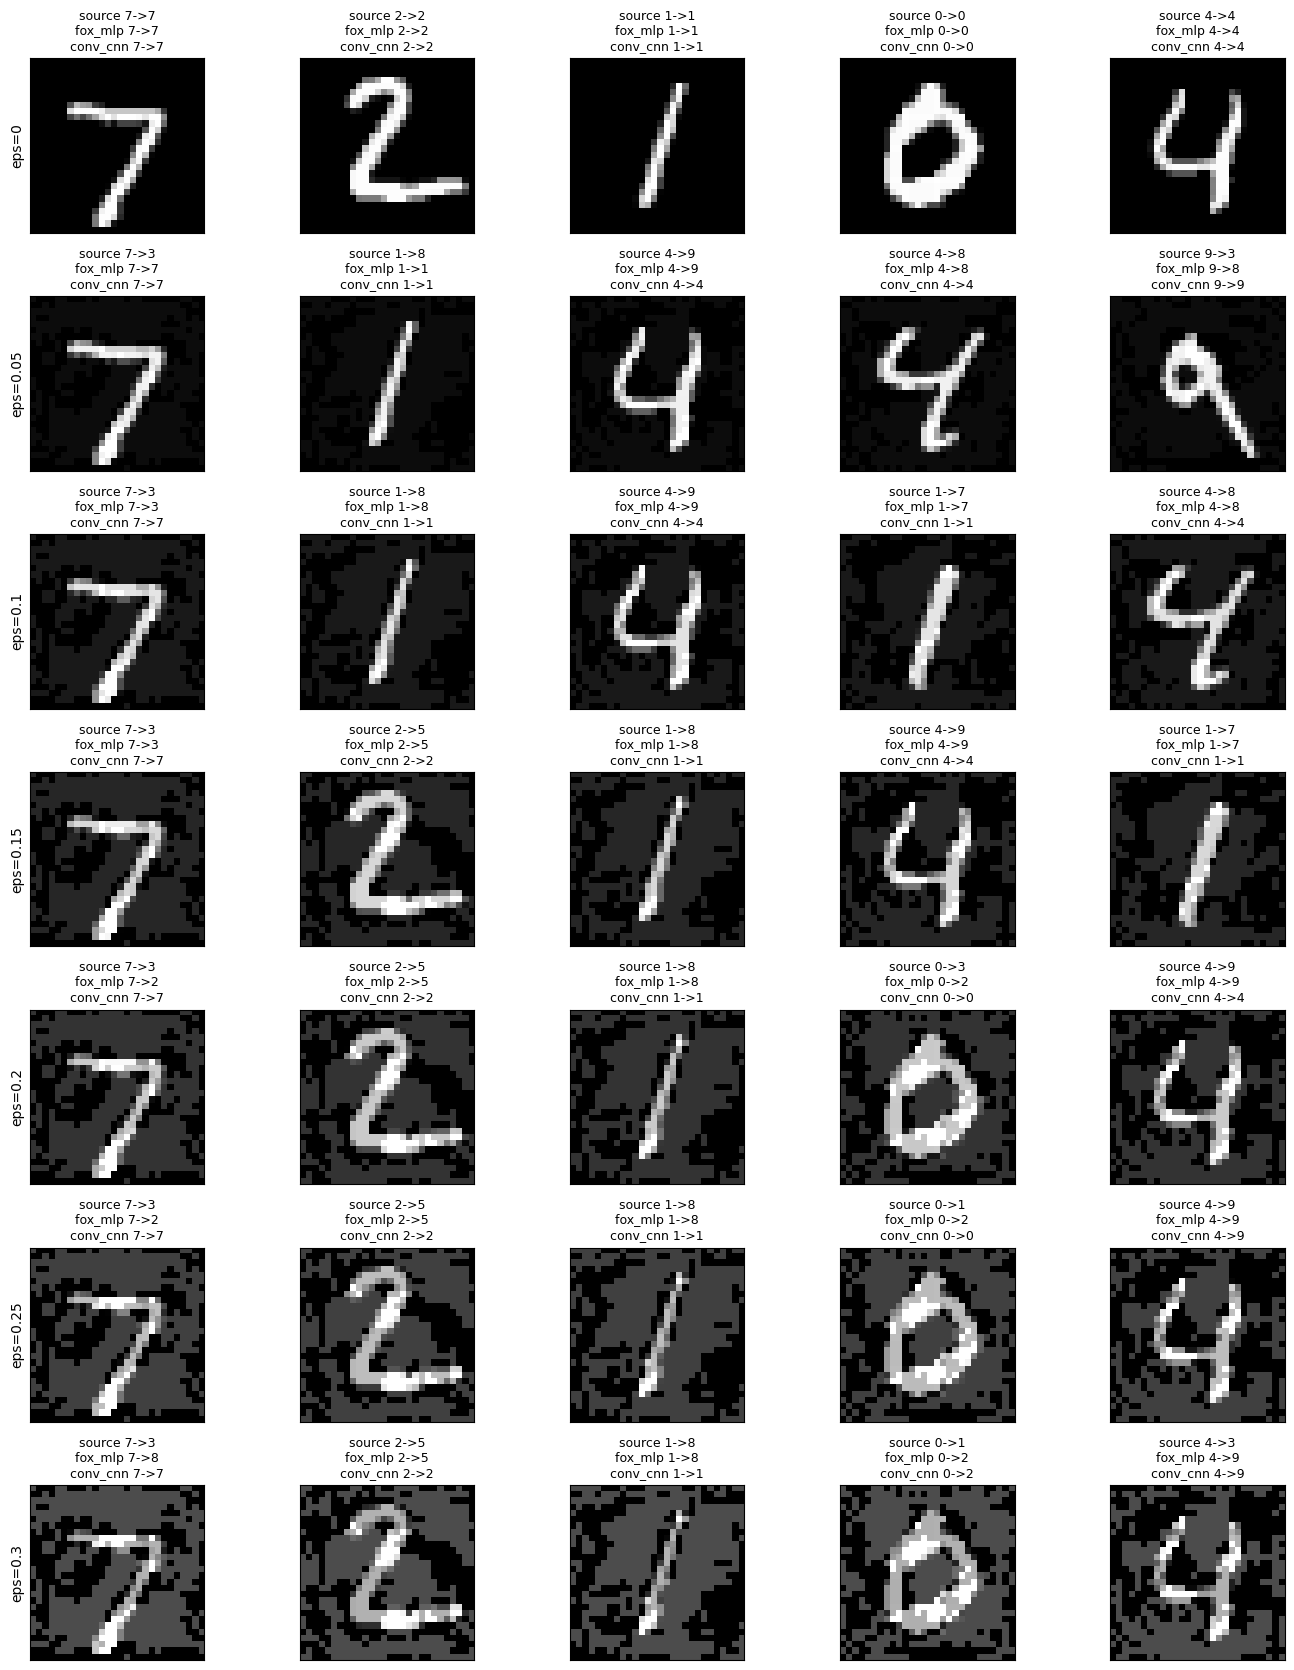

In [19]:
max_examples = max(len(result["examples"]) for result in results)
plt.figure(figsize=(2.8 * max_examples, 2.4 * len(results)))

plot_index = 0
for result in results:
    for example in result["examples"]:
        plot_index += 1
        plt.subplot(len(results), max_examples, plot_index)
        plt.imshow(example["image"], cmap="gray")
        plt.xticks([], [])
        plt.yticks([], [])
        target_lines = [
            f"{name} {example['target_clean'][name]}->{example['target_after'][name]}"
            for name in target_models
        ]
        plt.title(
            f"source {example['source_before']}->{example['source_after']}\n"
            + "\n".join(target_lines),
            fontsize=9,
        )
        if plot_index % max_examples == 1:
            plt.ylabel(f"eps={result['epsilon']}")

plt.tight_layout()
plt.show()